In [1]:
#Last edited on 22 October, 2025 Krishnendu

In [2]:
import numpy as np
import gwpopulation as gwpop
import matplotlib.pyplot as plt

In [3]:
from gwpopulation.models.mass import two_component_primary_mass_ratio
from gwpopulation.models.spin import iid_spin_magnitude_beta
from gwpopulation.models.redshift import PowerLawRedshift
from scipy.interpolate import interp1d


In [4]:
def save_samples_to_dat(filename, labels, *arrays):

    if len(arrays) != len(labels):
        raise ValueError("Number of arrays and number of labels must match.")
    
    array_lengths = [len(arr) for arr in arrays]
    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    data = np.column_stack(arrays)
    header = '\t'.join(labels)
    np.savetxt(filename, data, header=header, delimiter='\t', comments='')
    print(f"Saved data to {filename} with columns: {header}")

In [5]:
from gwbench.injections import  spin_sampler, redshift_lum_distance_sampler, angle_sampler, mass_sampler 
from astropy.cosmology import Planck15 as cosmo


/rds/homes/n/naderivk/.local/lib/python3.11/site-packages/gwbench/basic_relations.py:20: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import GreenwichMeanSiderealTime


In [6]:
# Check all hyper parameter values
hyperparams = {
    "alpha": 3.0,
    "beta": 1.0,
    "mmin": 5.0,
    "mmax": 100.0,
    "lam": 0.2,
    "mpp": 35.0,
    "sigpp": 5.0,
    "gaussian_mass_maximum": 80.0,
}

# --- 2. Define rejection sampler ---
def sample_masses(num_samples, hyperparams):
    samples_m1 = []
    samples_m2 = []

    # Estimate a conservative upper bound on p(m1, m2)
    m1_peak = hyperparams["mpp"]
    test_dict = {
        "mass_1": np.array([m1_peak]),
        "mass_2": np.array([m1_peak]),
        "mass_ratio": np.array([1.0]),
    }
    p_max = gwpop.models.mass.two_component_primary_mass_ratio(test_dict, **hyperparams)[0] * 1.2  # safety buffer

    while len(samples_m1) < num_samples:
        # Sample m1 from power-law envelope
        a = 1 - hyperparams["alpha"]
        m1 = (np.random.uniform(hyperparams["mmin"]**a, hyperparams["mmax"]**a))**(1 / a)

        # Sample q uniformly
        q = np.random.uniform(0.05, 1.0)
        m2 = q * m1

        if m2 < hyperparams["mmin"]:
            continue

        # Compute target probability
        d = {
            "mass_1": np.array([m1]),
            "mass_2": np.array([m2]),
            "mass_ratio": np.array([q]),
        }
        p = gwpop.models.mass.two_component_primary_mass_ratio(d, **hyperparams)[0]
        u = np.random.uniform(0, p_max)

        if u < p:
            samples_m1.append(m1)
            samples_m2.append(m2)

    return np.array(samples_m1), np.array(samples_m2)



In [7]:
num_samples = 10**5

In [8]:
# --- 3. Run sampling ---
m1, m2 = sample_masses(num_samples, hyperparams)
q = m2 / m1


(array([3.47986882e-01, 1.77461840e-01, 9.80124948e-02, 5.64151212e-02,
        3.33808974e-02, 2.11147051e-02, 1.16497615e-02, 7.24111099e-03,
        4.59592066e-03, 3.30843864e-03, 2.23943842e-03, 2.15360629e-03,
        1.57619011e-03, 1.74005146e-03, 1.60740179e-03, 1.39672292e-03,
        1.35770831e-03, 1.18604404e-03, 1.21725573e-03, 1.17824112e-03,
        8.58321346e-04, 7.10065841e-04, 4.60372358e-04, 3.74540224e-04,
        2.96511010e-04, 2.80905168e-04, 1.87270112e-04, 8.58321346e-05,
        7.02262920e-05, 6.24233706e-05, 2.34087640e-05, 1.56058427e-05,
        1.56058427e-05, 7.80292133e-06, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 7.80292133e-06, 0.00000000e+00, 1.56058427e-05]),
 array([ 5.00002238,  6.28159368,  7.56316498,  8.84473627, 10.12630757,
        11.40787886, 12.68945016, 13.97102146, 15.25259275, 16.53416405,
        17.81573534, 19.09730664, 20.37887794, 21.66044923, 22.94202053,
        24.22359182, 25.50516312, 26.78673442, 28.06830571,

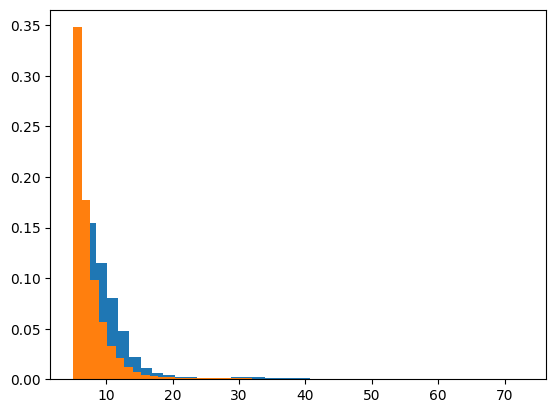

In [9]:
plt.hist(m1, 40, density=True)
plt.hist(m2, 40, density=True)


In [10]:
# check numbers
hyperparams_spin = {
    "alpha_chi": 2.0,
    "beta_chi": 5.0
}

def sample_spin_magnitudes(num_samples, hyperparams):
    chi_1_samples = []
    chi_2_samples = []

    # Estimate max of Beta PDF (conservatively)
    # Beta PDF peaks at (alpha - 1) / (alpha + beta - 2), if both > 1
    peak_val = (hyperparams["alpha_chi"] - 1) / (hyperparams["alpha_chi"] + hyperparams["beta_chi"] - 2)
    test_dict = {
        "a_1": np.array([peak_val]),
        "a_2": np.array([peak_val]),
    }
    p_max = iid_spin_magnitude_beta(test_dict, **hyperparams)[0] * 1.2  # safety buffer

    while len(chi_1_samples) < num_samples:
        chi_1 = np.random.uniform(0, 1)
        chi_2 = np.random.uniform(0, 1)

        data = {
            "a_1": np.array([chi_1]),
            "a_2": np.array([chi_2]),
        }
        p = iid_spin_magnitude_beta(data, **hyperparams)[0]
        u = np.random.uniform(0, p_max)

        if u < p:
            chi_1_samples.append(chi_1)
            chi_2_samples.append(chi_2)

    return np.array(chi_1_samples), np.array(chi_2_samples)



In [ ]:
# --- 3. Sample spins ---
chi_1, chi_2 = sample_spin_magnitudes(num_samples, hyperparams_spin)

In [ ]:
iota_vec, ra_vec, dec_vec, psi_vec = angle_sampler(num_samples, seed=20)


In [ ]:
z_model = PowerLawRedshift(z_max=2.5)


In [ ]:
z_grid = np.linspace(0.001, 2.7, num_samples)


In [ ]:
parameters = {"lamb": 2.7}

prob_z = z_model.probability({"redshift": z_grid}, **parameters)
prob_z /= np.trapz(prob_z, z_grid)  # just to be safe


In [ ]:
cdf = np.cumsum(prob_z)
cdf /= cdf[-1]
inverse_cdf = interp1d(cdf, z_grid, bounds_error=False, fill_value=(z_grid[0], z_grid[-1]))


In [ ]:
u = np.random.uniform(0, 1, size=num_samples)
z_samples = inverse_cdf(u)

dL_samples = cosmo.luminosity_distance(z_samples).value  # in Mpc


In [ ]:
plt.hist(dL_samples, bins=100, density=True, histtype='step', label='Luminosity Distance')
plt.xlabel('Luminosity Distance [Mpc]')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
save_samples_to_dat(
    "/rds/projects/p/pratteng-uob-3g/git_hub_ce_stm/CE_STM_CBC/pop_models/stellar_mass_BHs/data/stellar_mass_population_GWTC-3.dat",
    ["m1", "m2", "chi_1", "chi_2", "iota_vec", "ra_vec", "dec_vec", "psi_vec", "z_samples", "dL_samples"],
    m1, m2, chi_1, chi_2, iota_vec, ra_vec, dec_vec, psi_vec, z_samples, dL_samples
)